In [9]:
import re
from statistics import mean
import json

# Initialize lists to store metrics
stereo_odom_data = {
    'quality': [],
    'std_dev_pos': [],
    'std_dev_rot': [],
    'update_time': [],
    'delay': []
}
rtabmap_data = {
    'rate': [],
    'conversion': [],
    'rtabmap_time': [],
    'maps_update': [],
    'pub_time': [],
    'delay': []
}

# Regular expressions for parsing
stereo_odom_pattern = re.compile(
    r'\[stereo_odometry-5\] \[INFO\] \[\d+\.\d+\] \[stereo_odometry\]: Odom: quality=(\d+), std dev=([\d.]+)m\|([\d.]+)rad, update time=([\d.]+)s delay=([\d.]+)s'
)
rtabmap_pattern = re.compile(
    r'\[rtabmap-6\] \[INFO\] \[\d+\.\d+\] \[rtabmap\]: rtabmap \(\d+\): Rate=([\d.]+)s, Limit=[\d.]+s, Conversion=([\d.]+)s, RTAB-Map=([\d.]+)s, Maps update=([\d.]+)s pub=([\d.]+)s delay=([\d.]+)s'
)

# Read and parse the log file
with open('l_orin_vslam.log', 'r') as file:
    for line in file:
        # Parse stereo_odometry lines
        stereo_match = stereo_odom_pattern.search(line)
        if stereo_match:
            stereo_odom_data['quality'].append(int(stereo_match.group(1)))
            stereo_odom_data['std_dev_pos'].append(float(stereo_match.group(2)))
            stereo_odom_data['std_dev_rot'].append(float(stereo_match.group(3)))
            stereo_odom_data['update_time'].append(float(stereo_match.group(4)))
            stereo_odom_data['delay'].append(float(stereo_match.group(5)))
        
        # Parse rtabmap lines
        rtabmap_match = rtabmap_pattern.search(line)
        if rtabmap_match:
            rtabmap_data['rate'].append(float(rtabmap_match.group(1)))
            rtabmap_data['conversion'].append(float(rtabmap_match.group(2)))
            rtabmap_data['rtabmap_time'].append(float(rtabmap_match.group(3)))
            rtabmap_data['maps_update'].append(float(rtabmap_match.group(4)))
            rtabmap_data['pub_time'].append(float(rtabmap_match.group(5)))
            rtabmap_data['delay'].append(float(rtabmap_match.group(6)))

# Calculate statistics
def calculate_stats(data_list):
    return {
        'max': max(data_list) if data_list else 0,
        'min': min(data_list) if data_list else 0,
        'avg': mean(data_list) if data_list else 0
    }

stereo_stats = {key: calculate_stats(values) for key, values in stereo_odom_data.items()}
rtabmap_stats = {key: calculate_stats(values) for key, values in rtabmap_data.items()}

print("Stereo Odometry 日志条数：", len(stereo_odom_data['quality']))
print("RTAB-Map 日志条数：", len(rtabmap_data['rate']))

# Generate Markdown table
table = """
| **Metric**                          | **Maximum** | **Minimum** | **Average** |
|-------------------------------------|-------------|-------------|-------------|
| **Stereo Odometry**                 |             |             |             |
| Quality                             | {stereo_quality_max} | {stereo_quality_min} | {stereo_quality_avg:.2f} |
| Std Dev (Position, m)               | {stereo_std_dev_pos_max:.6f} | {stereo_std_dev_pos_min:.6f} | {stereo_std_dev_pos_avg:.6f} |
| Std Dev (Rotation, rad)             | {stereo_std_dev_rot_max:.6f} | {stereo_std_dev_rot_min:.6f} | {stereo_std_dev_rot_avg:.6f} |
| Update Time (s)                     | {stereo_update_time_max:.6f} | {stereo_update_time_min:.6f} | {stereo_update_time_avg:.6f} |
| Delay (s)                           | {stereo_delay_max:.6f} | {stereo_delay_min:.6f} | {stereo_delay_avg:.6f} |
| **RTAB-Map**                        |             |             |             |
| Rate (s)                            | {rtabmap_rate_max:.2f} | {rtabmap_rate_min:.2f} | {rtabmap_rate_avg:.2f} |
| Conversion Time (s)                 | {rtabmap_conversion_max:.6f} | {rtabmap_conversion_min:.6f} | {rtabmap_conversion_avg:.6f} |
| RTAB-Map Processing Time (s)        | {rtabmap_rtabmap_time_max:.6f} | {rtabmap_rtabmap_time_min:.6f} | {rtabmap_rtabmap_time_avg:.6f} |
| Maps Update Time (s)                | {rtabmap_maps_update_max:.6f} | {rtabmap_maps_update_min:.6f} | {rtabmap_maps_update_avg:.6f} |
| Publication Time (s)                | {rtabmap_pub_time_max:.6f} | {rtabmap_pub_time_min:.6f} | {rtabmap_pub_time_avg:.6f} |
| Delay (s)                           | {rtabmap_delay_max:.6f} | {rtabmap_delay_min:.6f} | {rtabmap_delay_avg:.6f} |
""".format(
    stereo_quality_max=stereo_stats['quality']['max'],
    stereo_quality_min=stereo_stats['quality']['min'],
    stereo_quality_avg=stereo_stats['quality']['avg'],
    stereo_std_dev_pos_max=stereo_stats['std_dev_pos']['max'],
    stereo_std_dev_pos_min=stereo_stats['std_dev_pos']['min'],
    stereo_std_dev_pos_avg=stereo_stats['std_dev_pos']['avg'],
    stereo_std_dev_rot_max=stereo_stats['std_dev_rot']['max'],
    stereo_std_dev_rot_min=stereo_stats['std_dev_rot']['min'],
    stereo_std_dev_rot_avg=stereo_stats['std_dev_rot']['avg'],
    stereo_update_time_max=stereo_stats['update_time']['max'],
    stereo_update_time_min=stereo_stats['update_time']['min'],
    stereo_update_time_avg=stereo_stats['update_time']['avg'],
    stereo_delay_max=stereo_stats['delay']['max'],
    stereo_delay_min=stereo_stats['delay']['min'],
    stereo_delay_avg=stereo_stats['delay']['avg'],
    rtabmap_rate_max=rtabmap_stats['rate']['max'],
    rtabmap_rate_min=rtabmap_stats['rate']['min'],
    rtabmap_rate_avg=rtabmap_stats['rate']['avg'],
    rtabmap_conversion_max=rtabmap_stats['conversion']['max'],
    rtabmap_conversion_min=rtabmap_stats['conversion']['min'],
    rtabmap_conversion_avg=rtabmap_stats['conversion']['avg'],
    rtabmap_rtabmap_time_max=rtabmap_stats['rtabmap_time']['max'],
    rtabmap_rtabmap_time_min=rtabmap_stats['rtabmap_time']['min'],
    rtabmap_rtabmap_time_avg=rtabmap_stats['rtabmap_time']['avg'],
    rtabmap_maps_update_max=rtabmap_stats['maps_update']['max'],
    rtabmap_maps_update_min=rtabmap_stats['maps_update']['min'],
    rtabmap_maps_update_avg=rtabmap_stats['maps_update']['avg'],
    rtabmap_pub_time_max=rtabmap_stats['pub_time']['max'],
    rtabmap_pub_time_min=rtabmap_stats['pub_time']['min'],
    rtabmap_pub_time_avg=rtabmap_stats['pub_time']['avg'],
    rtabmap_delay_max=rtabmap_stats['delay']['max'],
    rtabmap_delay_min=rtabmap_stats['delay']['min'],
    rtabmap_delay_avg=rtabmap_stats['delay']['avg']
)

# Output the table to a file
with open('vslam_stats.md', 'w') as f:
    f.write(table)

# Print the table
print("Statistical Analysis Table:")
print(table)

# Generate Chart.js configurations
stereo_chart_config = {
    "type": "bar",
    "data": {
        "labels": ["Quality", "Std Dev (Pos, m)", "Std Dev (Rot, rad)", "Update Time (s)", "Delay (s)"],
        "datasets": [
            {
                "label": "Maximum",
                "data": [
                    stereo_stats['quality']['max'],
                    stereo_stats['std_dev_pos']['max'],
                    stereo_stats['std_dev_rot']['max'],
                    stereo_stats['update_time']['max'],
                    stereo_stats['delay']['max']
                ],
                "backgroundColor": "#4CAF50",
                "borderColor": "#388E3C",
                "borderWidth": 1
            },
            {
                "label": "Minimum",
                "data": [
                    stereo_stats['quality']['min'],
                    stereo_stats['std_dev_pos']['min'],
                    stereo_stats['std_dev_rot']['min'],
                    stereo_stats['update_time']['min'],
                    stereo_stats['delay']['min']
                ],
                "backgroundColor": "#F44336",
                "borderColor": "#D32F2F",
                "borderWidth": 1
            },
            {
                "label": "Average",
                "data": [
                    stereo_stats['quality']['avg'],
                    stereo_stats['std_dev_pos']['avg'],
                    stereo_stats['std_dev_rot']['avg'],
                    stereo_stats['update_time']['avg'],
                    stereo_stats['delay']['avg']
                ],
                "backgroundColor": "#2196F3",
                "borderColor": "#1976D2",
                "borderWidth": 1
            }
        ]
    },
    "options": {
        "plugins": {
            "title": {
                "display": True,
                "text": "Stereo Odometry Metrics"
            },
            "legend": {
                "display": True
            }
        },
        "scales": {
            "y": {
                "beginAtZero": True,
                "title": {
                    "display": True,
                    "text": "Value"
                }
            },
            "x": {
                "title": {
                    "display": True,
                    "text": "Metrics"
                }
            }
        }
    }
}

rtabmap_chart_config = {
    "type": "bar",
    "data": {
        "labels": ["Rate (s)", "Conversion (s)", "RTAB-Map Time (s)", "Maps Update (s)", "Pub Time (s)", "Delay (s)"],
        "datasets": [
            {
                "label": "Maximum",
                "data": [
                    rtabmap_stats['rate']['max'],
                    rtabmap_stats['conversion']['max'],
                    rtabmap_stats['rtabmap_time']['max'],
                    rtabmap_stats['maps_update']['max'],
                    rtabmap_stats['pub_time']['max'],
                    rtabmap_stats['delay']['max']
                ],
                "backgroundColor": "#4CAF50",
                "borderColor": "#388E3C",
                "borderWidth": 1
            },
            {
                "label": "Minimum",
                "data": [
                    rtabmap_stats['rate']['min'],
                    rtabmap_stats['conversion']['min'],
                    rtabmap_stats['rtabmap_time']['min'],
                    rtabmap_stats['maps_update']['min'],
                    rtabmap_stats['pub_time']['min'],
                    rtabmap_stats['delay']['min']
                ],
                "backgroundColor": "#F44336",
                "borderColor": "#D32F2F",
                "borderWidth": 1
            },
            {
                "label": "Average",
                "data": [
                    rtabmap_stats['rate']['avg'],
                    rtabmap_stats['conversion']['avg'],
                    rtabmap_stats['rtabmap_time']['avg'],
                    rtabmap_stats['maps_update']['avg'],
                    rtabmap_stats['pub_time']['avg'],
                    rtabmap_stats['delay']['avg']
                ],
                "backgroundColor": "#2196F3",
                "borderColor": "#1976D2",
                "borderWidth": 1
            }
        ]
    },
    "options": {
        "plugins": {
            "title": {
                "display": True,
                "text": "RTAB-Map Metrics"
            },
            "legend": {
                "display": True
            }
        },
        "scales": {
            "y": {
                "beginAtZero": True,
                "title": {
                    "display": True,
                    "text": "Value (s)"
                }
            },
            "x": {
                "title": {
                    "display": True,
                    "text": "Metrics"
                }
            }
        }
    }
}

# Output Chart.js configurations
print("\nStereo Odometry Chart:")
print("```chartjs")
print(json.dumps(stereo_chart_config, indent=2))
print("```")

print("\nRTAB-Map Chart:")
print("```chartjs")
print(json.dumps(rtabmap_chart_config, indent=2))
print("```")

# Save Chart.js configurations to files
with open('stereo_odom_chart.json', 'w') as f:
    json.dump(stereo_chart_config, f, indent=2)
with open('rtabmap_chart.json', 'w') as f:
    json.dump(rtabmap_chart_config, f, indent=2)


Stereo Odometry 日志条数： 2810
RTAB-Map 日志条数： 1812
Statistical Analysis Table:

| **Metric**                          | **Maximum** | **Minimum** | **Average** |
|-------------------------------------|-------------|-------------|-------------|
| **Stereo Odometry**                 |             |             |             |
| Quality                             | 164 | 0 | 104.33 |
| Std Dev (Position, m)               | 99.995000 | 0.000472 | 0.043855 |
| Std Dev (Rotation, rad)             | 99.995000 | 0.000173 | 0.111158 |
| Update Time (s)                     | 0.147820 | 0.011475 | 0.046211 |
| Delay (s)                           | 0.391312 | 0.079908 | 0.130915 |
| **RTAB-Map**                        |             |             |             |
| Rate (s)                            | 0.07 | 0.07 | 0.07 |
| Conversion Time (s)                 | 0.016000 | 0.001300 | 0.004714 |
| RTAB-Map Processing Time (s)        | 0.169900 | 0.025800 | 0.043079 |
| Maps Update Time (s)              

In [ ]:
# import sys
# !{sys.executable} -m pip install pygments

: 

In [2]:
import re
from statistics import mean, median
import numpy as np

# Initialize lists to store metrics
stereo_odom_data = {
    'quality': [],
    'std_dev_pos': [],
    'std_dev_rot': [],
    'update_time': [],
    'delay': []
}
rtabmap_data = {
    'rate': [],
    'conversion': [],
    'rtabmap_time': [],
    'maps_update': [],
    'pub_time': [],
    'delay': []
}

# Regular expressions for parsing
stereo_odom_pattern = re.compile(
    r'\[stereo_odometry-5\] \[INFO\] \[\d+\.\d+\] \[stereo_odometry\]: Odom: quality=(\d+), std dev=([\d.]+)m\|([\d.]+)rad, update time=([\d.]+)s delay=([\d.]+)s'
)
rtabmap_pattern = re.compile(
    r'\[rtabmap-6\] \[INFO\] \[\d+\.\d+\] \[rtabmap\]: rtabmap \(\d+\): Rate=([\d.]+)s, Limit=[\d.]+s, Conversion=([\d.]+)s, RTAB-Map=([\d.]+)s, Maps update=([\d.]+)s pub=([\d.]+)s delay=([\d.]+)s'
)

# Read and parse the log file
with open('orin_vslam.log', 'r') as file:
    for line in file:
        # Parse stereo_odometry lines
        stereo_match = stereo_odom_pattern.search(line)
        if stereo_match:
            stereo_odom_data['quality'].append(int(stereo_match.group(1)))
            stereo_odom_data['std_dev_pos'].append(float(stereo_match.group(2)))
            stereo_odom_data['std_dev_rot'].append(float(stereo_match.group(3)))
            stereo_odom_data['update_time'].append(float(stereo_match.group(4)))
            stereo_odom_data['delay'].append(float(stereo_match.group(5)))
        # Parse rtabmap lines
        rtabmap_match = rtabmap_pattern.search(line)
        if rtabmap_match:
            rtabmap_data['rate'].append(float(rtabmap_match.group(1)))
            rtabmap_data['conversion'].append(float(rtabmap_match.group(2)))
            rtabmap_data['rtabmap_time'].append(float(rtabmap_match.group(3)))
            rtabmap_data['maps_update'].append(float(rtabmap_match.group(4)))
            rtabmap_data['pub_time'].append(float(rtabmap_match.group(5)))
            rtabmap_data['delay'].append(float(rtabmap_match.group(6)))

def calculate_stats(data_list):
    return {
        'max': max(data_list) if data_list else 0,
        'min': min(data_list) if data_list else 0,
        'avg': mean(data_list) if data_list else 0,
        'median': median(data_list) if data_list else 0,
        'q1': np.percentile(data_list, 25) if data_list else 0,
        'q3': np.percentile(data_list, 75) if data_list else 0
    }

stereo_stats = {key: calculate_stats(values) for key, values in stereo_odom_data.items()}
rtabmap_stats = {key: calculate_stats(values) for key, values in rtabmap_data.items()}

print("Stereo Odometry 日志条数：", len(stereo_odom_data['quality']))
print("RTAB-Map 日志条数：", len(rtabmap_data['rate']))

# LaTeX表格输出
latex_table = r"""
\begin{{table}}[htbp]
\centering
\begin{{tabular}}{{|l|c|c|c|}}
\hline
\textbf{{Metric}} & \textbf{{Maximum}} & \textbf{{Minimum}} & \textbf{{Average}} \\
\hline
\multicolumn{{4}}{{|c|}}{{\textbf{{Stereo Odometry}}}} \\
Quality & {quality_max} & {quality_min} & {quality_avg:.2f} \\
Std Dev (Position, m) & {std_dev_pos_max:.6f} & {std_dev_pos_min:.6f} & {std_dev_pos_avg:.6f} \\
Std Dev (Rotation, rad) & {std_dev_rot_max:.6f} & {std_dev_rot_min:.6f} & {std_dev_rot_avg:.6f} \\
Update Time (s) & {update_time_max:.6f} & {update_time_min:.6f} & {update_time_avg:.6f} \\
Delay (s) & {delay_max:.6f} & {delay_min:.6f} & {delay_avg:.6f} \\
\hline
\multicolumn{{4}}{{|c|}}{{\textbf{{RTAB-Map}}}} \\
Rate (s) & {rate_max:.2f} & {rate_min:.2f} & {rate_avg:.2f} \\
Conversion Time (s) & {conversion_max:.6f} & {conversion_min:.6f} & {conversion_avg:.6f} \\
RTAB-Map Processing Time (s) & {rtabmap_time_max:.6f} & {rtabmap_time_min:.6f} & {rtabmap_time_avg:.6f} \\
Maps Update Time (s) & {maps_update_max:.6f} & {maps_update_min:.6f} & {maps_update_avg:.6f} \\
Publication Time (s) & {pub_time_max:.6f} & {pub_time_min:.6f} & {pub_time_avg:.6f} \\
Delay (s) & {delay2_max:.6f} & {delay2_min:.6f} & {delay2_avg:.6f} \\
\hline
\end{{tabular}}
\caption{{统计结果表}}
\end{{table}}
""".format(
    quality_max=stereo_stats['quality']['max'],
    quality_min=stereo_stats['quality']['min'],
    quality_avg=stereo_stats['quality']['avg'],
    std_dev_pos_max=stereo_stats['std_dev_pos']['max'],
    std_dev_pos_min=stereo_stats['std_dev_pos']['min'],
    std_dev_pos_avg=stereo_stats['std_dev_pos']['avg'],
    std_dev_rot_max=stereo_stats['std_dev_rot']['max'],
    std_dev_rot_min=stereo_stats['std_dev_rot']['min'],
    std_dev_rot_avg=stereo_stats['std_dev_rot']['avg'],
    update_time_max=stereo_stats['update_time']['max'],
    update_time_min=stereo_stats['update_time']['min'],
    update_time_avg=stereo_stats['update_time']['avg'],
    delay_max=stereo_stats['delay']['max'],
    delay_min=stereo_stats['delay']['min'],
    delay_avg=stereo_stats['delay']['avg'],
    rate_max=rtabmap_stats['rate']['max'],
    rate_min=rtabmap_stats['rate']['min'],
    rate_avg=rtabmap_stats['rate']['avg'],
    conversion_max=rtabmap_stats['conversion']['max'],
    conversion_min=rtabmap_stats['conversion']['min'],
    conversion_avg=rtabmap_stats['conversion']['avg'],
    rtabmap_time_max=rtabmap_stats['rtabmap_time']['max'],
    rtabmap_time_min=rtabmap_stats['rtabmap_time']['min'],
    rtabmap_time_avg=rtabmap_stats['rtabmap_time']['avg'],
    maps_update_max=rtabmap_stats['maps_update']['max'],
    maps_update_min=rtabmap_stats['maps_update']['min'],
    maps_update_avg=rtabmap_stats['maps_update']['avg'],
    pub_time_max=rtabmap_stats['pub_time']['max'],
    pub_time_min=rtabmap_stats['pub_time']['min'],
    pub_time_avg=rtabmap_stats['pub_time']['avg'],
    delay2_max=rtabmap_stats['delay']['max'],
    delay2_min=rtabmap_stats['delay']['min'],
    delay2_avg=rtabmap_stats['delay']['avg'],
)
print("\nLaTeX统计表格：")
print(latex_table)

# LaTeX箱线图数据输出（Stereo Odometry为例）
print("\nStereo Odometry 箱线图 LaTeX数据：")
for key in stereo_odom_data:
    stats = stereo_stats[key]
    print(f"% {key}")
    print(
        f"\\addplot+[\n"
        f"    boxplot prepared={{\n"
        f"        median={stats['median']},\n"
        f"        upper quartile={stats['q3']},\n"
        f"        lower quartile={stats['q1']},\n"
        f"        upper whisker={stats['max']},\n"
        f"        lower whisker={stats['min']}\n"
        f"    }},\n"
        f"] coordinates {{}};\n"
    )

print("% RTAB-Map 箱线图 LaTeX数据：")
for key in rtabmap_data:
    stats = rtabmap_stats[key]
    print(f"% {key}")
    print(
        f"\\addplot+[\n"
        f"    boxplot prepared={{\n"
        f"        median={stats['median']},\n"
        f"        upper quartile={stats['q3']},\n"
        f"        lower quartile={stats['q1']},\n"
        f"        upper whisker={stats['max']},\n"
        f"        lower whisker={stats['min']}\n"
        f"    }},\n"
        f"] coordinates {{}};\n"
    )

Stereo Odometry 日志条数： 10732
RTAB-Map 日志条数： 4204

LaTeX统计表格：

\begin{table}[htbp]
\centering
\begin{tabular}{|l|c|c|c|}
\hline
\textbf{Metric} & \textbf{Maximum} & \textbf{Minimum} & \textbf{Average} \\
\hline
\multicolumn{4}{|c|}{\textbf{Stereo Odometry}} \\
Quality & 157 & 0 & 90.06 \\
Std Dev (Position, m) & 99.995000 & 0.000000 & 0.020276 \\
Std Dev (Rotation, rad) & 99.995000 & 0.000000 & 0.090127 \\
Update Time (s) & 0.501643 & 0.010601 & 0.050368 \\
Delay (s) & 0.571397 & 0.079258 & 0.133900 \\
\hline
\multicolumn{4}{|c|}{\textbf{RTAB-Map}} \\
Rate (s) & 0.20 & 0.20 & 0.20 \\
Conversion Time (s) & 0.019000 & 0.001400 & 0.005081 \\
RTAB-Map Processing Time (s) & 0.298200 & 0.000200 & 0.058449 \\
Maps Update Time (s) & 0.045500 & 0.000000 & 0.017308 \\
Publication Time (s) & 0.534400 & 0.000000 & 0.020933 \\
Delay (s) & 0.757900 & 0.125000 & 0.245243 \\
\hline
\end{tabular}
\caption{统计结果表}
\end{table}


Stereo Odometry 箱线图 LaTeX数据：
% quality
\addplot+[
    boxplot prepared={
      

In [ ]:
import matplotlib.pyplot as plt

# Stereo Odometry 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [
        stereo_odom_data['quality'],
        stereo_odom_data['std_dev_pos'],
        stereo_odom_data['std_dev_rot'],
        stereo_odom_data['update_time'],
        stereo_odom_data['delay']
    ],
    labels=['Quality', 'Std Dev Pos', 'Std Dev Rot', 'Update Time', 'Delay'],
    patch_artist=True
)
plt.title('Stereo Odometry Metrics Boxplot')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# RTAB-Map 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [
        rtabmap_data['rate'],
        rtabmap_data['conversion'],
        rtabmap_data['rtabmap_time'],
        rtabmap_data['maps_update'],
        rtabmap_data['pub_time'],
        rtabmap_data['delay']
    ],
    labels=['Rate', 'Conversion', 'RTAB-Map Time', 'Maps Update', 'Pub Time', 'Delay'],
    patch_artist=True
)
plt.title('RTAB-Map Metrics Boxplot')
plt.ylabel('Time (s)')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

def min_max_normalize(data):
    arr = np.array(data)
    return (arr - arr.min()) / (arr.max() - arr.min()) if arr.max() > arr.min() else arr

# 对每个指标归一化
stereo_odom_norm = [min_max_normalize(stereo_odom_data[key]) for key in stereo_odom_data]
rtabmap_norm = [min_max_normalize(rtabmap_data[key]) for key in rtabmap_data]

plt.figure(figsize=(10, 6))
plt.boxplot(stereo_odom_norm, labels=list(stereo_odom_data.keys()), patch_artist=True)
plt.title('Stereo Odometry Metrics Boxplot (Normalized)')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(rtabmap_norm, labels=list(rtabmap_data.keys()), patch_artist=True)
plt.title('RTAB-Map Metrics Boxplot (Normalized)')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.show()

In [5]:
import pandas as pd
from IPython.display import display

# 构造统计数据
stereo_table = [
    ["Quality", stereo_stats['quality']['max'], stereo_stats['quality']['min'], f"{stereo_stats['quality']['avg']:.2f}"],
    ["Std Dev (Position, m)", f"{stereo_stats['std_dev_pos']['max']:.6f}", f"{stereo_stats['std_dev_pos']['min']:.6f}", f"{stereo_stats['std_dev_pos']['avg']:.6f}"],
    ["Std Dev (Rotation, rad)", f"{stereo_stats['std_dev_rot']['max']:.6f}", f"{stereo_stats['std_dev_rot']['min']:.6f}", f"{stereo_stats['std_dev_rot']['avg']:.6f}"],
    ["Update Time (s)", f"{stereo_stats['update_time']['max']:.6f}", f"{stereo_stats['update_time']['min']:.6f}", f"{stereo_stats['update_time']['avg']:.6f}"],
    ["Delay (s)", f"{stereo_stats['delay']['max']:.6f}", f"{stereo_stats['delay']['min']:.6f}", f"{stereo_stats['delay']['avg']:.6f}"],
]

rtabmap_table = [
    ["Rate (s)", f"{rtabmap_stats['rate']['max']:.2f}", f"{rtabmap_stats['rate']['min']:.2f}", f"{rtabmap_stats['rate']['avg']:.2f}"],
    ["Conversion Time (s)", f"{rtabmap_stats['conversion']['max']:.6f}", f"{rtabmap_stats['conversion']['min']:.6f}", f"{rtabmap_stats['conversion']['avg']:.6f}"],
    ["RTAB-Map Processing Time (s)", f"{rtabmap_stats['rtabmap_time']['max']:.6f}", f"{rtabmap_stats['rtabmap_time']['min']:.6f}", f"{rtabmap_stats['rtabmap_time']['avg']:.6f}"],
    ["Maps Update Time (s)", f"{rtabmap_stats['maps_update']['max']:.6f}", f"{rtabmap_stats['maps_update']['min']:.6f}", f"{rtabmap_stats['maps_update']['avg']:.6f}"],
    ["Publication Time (s)", f"{rtabmap_stats['pub_time']['max']:.6f}", f"{rtabmap_stats['pub_time']['min']:.6f}", f"{rtabmap_stats['pub_time']['avg']:.6f}"],
    ["Delay (s)", f"{rtabmap_stats['delay']['max']:.6f}", f"{rtabmap_stats['delay']['min']:.6f}", f"{rtabmap_stats['delay']['avg']:.6f}"],
]

# 合并为DataFrame
df_stereo = pd.DataFrame(stereo_table, columns=["Metric", "Maximum", "Minimum", "Average"])
df_rtabmap = pd.DataFrame(rtabmap_table, columns=["Metric", "Maximum", "Minimum", "Average"])

print("Stereo Odometry Metrics Table:")
display(df_stereo)

print("RTAB-Map Metrics Table:")
display(df_rtabmap)

Stereo Odometry Metrics Table:


,Metric,Maximum,Minimum,Average
0,Quality,157,0,90.06
1,"Std Dev (Position, m)",99.995000,0.000000,0.020276
2,"Std Dev (Rotation, rad)",99.995000,0.000000,0.090127
3,Update Time (s),0.501643,0.010601,0.050368
4,Delay (s),0.571397,0.079258,0.133900


RTAB-Map Metrics Table:


,Metric,Maximum,Minimum,Average
0,Rate (s),0.20,0.20,0.20
1,Conversion Time (s),0.019000,0.001400,0.005081
2,RTAB-Map Processing Time (s),0.298200,0.000200,0.058449
3,Maps Update Time (s),0.045500,0.000000,0.017308
4,Publication Time (s),0.534400,0.000000,0.020933
5,Delay (s),0.757900,0.125000,0.245243



Mapping Stereo Odometry


,Metric,Maximum,Minimum,Average
0,quality,157.000000,0.000000,90.059728
1,std_dev_pos,99.995000,0.000000,0.020276
2,std_dev_rot,99.995000,0.000000,0.090127
3,update_time,0.501643,0.010601,0.050368
4,delay,0.571397,0.079258,0.133900



Localization Stereo Odometry


,Metric,Maximum,Minimum,Average
0,quality,164.000000,0.000000,104.331317
1,std_dev_pos,99.995000,0.000472,0.043855
2,std_dev_rot,99.995000,0.000173,0.111158
3,update_time,0.147820,0.011475,0.046211
4,delay,0.391312,0.079908,0.130915



Mapping RTAB-Map


,Metric,Maximum,Minimum,Average
0,rate,0.2000,0.2000,0.200000
1,conversion,0.0190,0.0014,0.005081
2,rtabmap_time,0.2982,0.0002,0.058449
3,maps_update,0.0455,0.0000,0.017308
4,pub_time,0.5344,0.0000,0.020933
5,delay,0.7579,0.1250,0.245243



Localization RTAB-Map


,Metric,Maximum,Minimum,Average
0,rate,0.0700,0.0700,0.070000
1,conversion,0.0160,0.0013,0.004714
2,rtabmap_time,0.1699,0.0258,0.043079
3,maps_update,0.1266,0.0005,0.013204
4,pub_time,0.0696,0.0001,0.013038
5,delay,0.4952,0.1316,0.221912


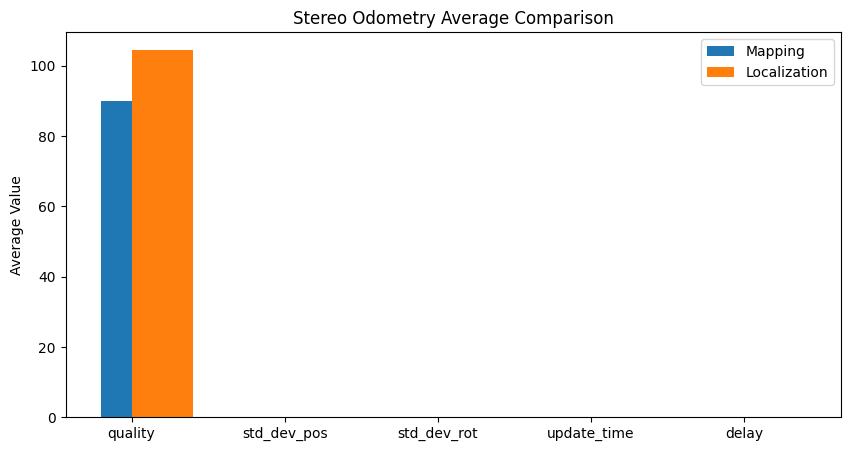

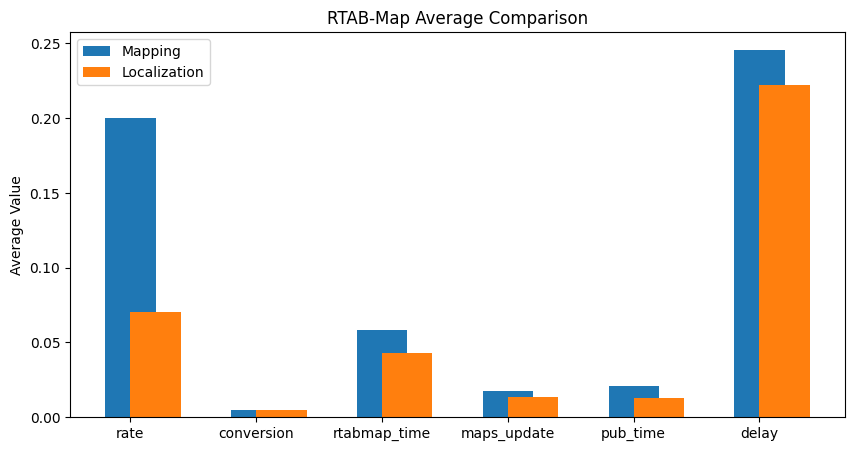

In [8]:
import re
from statistics import mean
import matplotlib.pyplot as plt
import pandas as pd

def parse_log(filename):
    stereo_odom_data = { 'quality': [], 'std_dev_pos': [], 'std_dev_rot': [], 'update_time': [], 'delay': [] }
    rtabmap_data = { 'rate': [], 'conversion': [], 'rtabmap_time': [], 'maps_update': [], 'pub_time': [], 'delay': [] }
    stereo_odom_pattern = re.compile(
        r'\[stereo_odometry-5\] \[INFO\] \[\d+\.\d+\] \[stereo_odometry\]: Odom: quality=(\d+), std dev=([\d.]+)m\|([\d.]+)rad, update time=([\d.]+)s delay=([\d.]+)s'
    )
    rtabmap_pattern = re.compile(
        r'\[rtabmap-6\] \[INFO\] \[\d+\.\d+\] \[rtabmap\]: rtabmap \(\d+\): Rate=([\d.]+)s, Limit=[\d.]+s, Conversion=([\d.]+)s, RTAB-Map=([\d.]+)s, Maps update=([\d.]+)s pub=([\d.]+)s delay=([\d.]+)s'
    )
    with open(filename, 'r') as file:
        for line in file:
            stereo_match = stereo_odom_pattern.search(line)
            if stereo_match:
                stereo_odom_data['quality'].append(int(stereo_match.group(1)))
                stereo_odom_data['std_dev_pos'].append(float(stereo_match.group(2)))
                stereo_odom_data['std_dev_rot'].append(float(stereo_match.group(3)))
                stereo_odom_data['update_time'].append(float(stereo_match.group(4)))
                stereo_odom_data['delay'].append(float(stereo_match.group(5)))
            rtabmap_match = rtabmap_pattern.search(line)
            if rtabmap_match:
                rtabmap_data['rate'].append(float(rtabmap_match.group(1)))
                rtabmap_data['conversion'].append(float(rtabmap_match.group(2)))
                rtabmap_data['rtabmap_time'].append(float(rtabmap_match.group(3)))
                rtabmap_data['maps_update'].append(float(rtabmap_match.group(4)))
                rtabmap_data['pub_time'].append(float(rtabmap_match.group(5)))
                rtabmap_data['delay'].append(float(rtabmap_match.group(6)))
    return stereo_odom_data, rtabmap_data

def calc_stats(data):
    return {k: {'max': max(v) if v else 0, 'min': min(v) if v else 0, 'avg': mean(v) if v else 0} for k, v in data.items()}

# Read mapping and localization logs
stereo_odom_map, rtabmap_map = parse_log('orin_vslam.log')
stereo_odom_loc, rtabmap_loc = parse_log('l_orin_vslam.log')

# Statistical analysis
stereo_stats_map = calc_stats(stereo_odom_map)
rtabmap_stats_map = calc_stats(rtabmap_map)
stereo_stats_loc = calc_stats(stereo_odom_loc)
rtabmap_stats_loc = calc_stats(rtabmap_loc)

# Generate tables
def stats_to_df(stats, title):
    df = pd.DataFrame([
        [k, v['max'], v['min'], v['avg']] for k, v in stats.items()
    ], columns=['Metric', 'Maximum', 'Minimum', 'Average'])
    print(f"\n{title}")
    display(df)

stats_to_df(stereo_stats_map, "Mapping Stereo Odometry")
stats_to_df(stereo_stats_loc, "Localization Stereo Odometry")
stats_to_df(rtabmap_stats_map, "Mapping RTAB-Map")
stats_to_df(rtabmap_stats_loc, "Localization RTAB-Map")

# Bar chart comparison (Stereo Odometry)
metrics = list(stereo_stats_map.keys())
map_avg = [stereo_stats_map[m]['avg'] for m in metrics]
loc_avg = [stereo_stats_loc[m]['avg'] for m in metrics]

plt.figure(figsize=(10,5))
plt.bar(metrics, map_avg, width=0.4, label='Mapping', align='center')
plt.bar(metrics, loc_avg, width=0.4, label='Localization', align='edge')
plt.ylabel('Average Value')
plt.title('Stereo Odometry Average Comparison')
plt.legend()
plt.show()

# Bar chart comparison (RTAB-Map)
metrics = list(rtabmap_stats_map.keys())
map_avg = [rtabmap_stats_map[m]['avg'] for m in metrics]
loc_avg = [rtabmap_stats_loc[m]['avg'] for m in metrics]

plt.figure(figsize=(10,5))
plt.bar(metrics, map_avg, width=0.4, label='Mapping', align='center')
plt.bar(metrics, loc_avg, width=0.4, label='Localization', align='edge')
plt.ylabel('Average Value')
plt.title('RTAB-Map Average Comparison')
plt.legend()
plt.show()

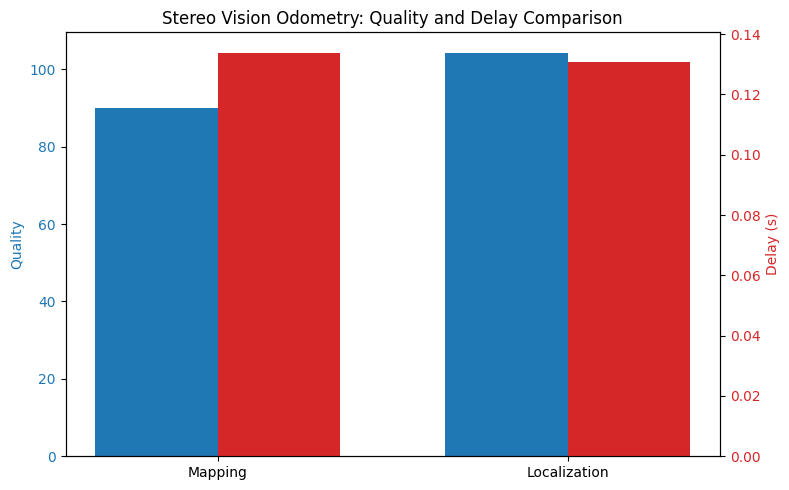

In [12]:
import matplotlib.pyplot as plt

metrics = ['quality', 'delay']

map_quality = stereo_stats_map['quality']['avg']
loc_quality = stereo_stats_loc['quality']['avg']
map_delay = stereo_stats_map['delay']['avg']
loc_delay = stereo_stats_loc['delay']['avg']

fig, ax1 = plt.subplots(figsize=(8,5))

bar_width = 0.35
x = [0, 1]  # 0: Mapping, 1: Localization

# Quality (left y-axis)
ax1.bar(x, [map_quality, loc_quality], bar_width, color='tab:blue', label='Quality')
# Delay (right y-axis)
ax2 = ax1.twinx()
ax2.bar([i + bar_width for i in x], [map_delay, loc_delay], bar_width, color='tab:red', label='Delay')

# Set xticks to center between bars
xtick_pos = [i + bar_width / 2 for i in x]
ax1.set_xticks(xtick_pos)
ax1.set_xticklabels(['Mapping', 'Localization'])

ax1.set_ylabel('Quality', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylabel('Delay (s)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Stereo Vision Odometry: Quality and Delay Comparison')
fig.tight_layout()
plt.show()